# GO proposal: Asteroseismology of bright $\gamma$ Dor and SPB stars


Author: Nicholas Jannsen

Last checked: 2026-01-30

PlatoSim version: `3.7.0-165-gae316c48`

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
# Python standard
import os
import sys
import glob

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from astropy.coordinates import SkyCoord
from astropy import units as u
from tqdm import tqdm 

# PlatoSim functions
import platosim.plot      as pt
import platosim.utilities as ut 
import platosim.starquery as sq
from platosim.lightcurve   import LightCurve
from platosim.utilities    import getFunctions
from platosim.matplotlibrc import setup_notebook
setup_notebook()

# Configure notebook 
from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In preparation for Gaia DR4, the Gaia archive is in evolution. Unfortunately, it may be unstable at times and particular types of queries may time out. Please consider registering for a user account (https://www.cosmos.esa.int/web/gaia-users/register). For questions or advice, please contact the Gaia helpdesk (https://www.cosmos.esa.int/web/gaia/gaia-helpdesk).


In [3]:
# Set global paths
hdir = Path(os.getenv('PLATO_PROJECT_HOME')) / 'inputfiles/data_picsim'
path = Path(os.getenv('PLATO_WORKDIR')) / 'go_gmode'
idir = path / 'input'
odir = path / 'output'
fdir = path / 'figures'
ddir = path / 'data'

---
## 1. Benchmark $\gamma$ Dor and SPB stars
---

### Load catalogue

In [5]:
filename = ddir / '20260130-SPB-GDOR-PLATO-GO-candidates.xlsx'
df = pd.read_excel(filename, skiprows=[1, 2, 3, 45, 46, 47])
dt = pd.DataFrame({
    'ID':df['#HDid'],
    'ra':df['RA(deg)'],
    'dec':df['Dec(deg)']
})

In [6]:
# Text query of one single star
dx = sq.simbadQuery(dt.ID.iloc[0], radius=15, maglim=21)
dx

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag
0,0.000000,418916648901801728,6.065337,52.019900,5.521783,-0.138113,2.462082,0.330046,15.504211,-4.061359,4.407852,15002.303711,3.4612,5.572810
1,8.236693,418917404816849024,6.061691,52.019003,18.225454,0.684354,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.014267


In [7]:
# Query sources from Gaia DR3 database
df = pd.DataFrame()
for n in tqdm(dt.ID, bar_format=ut.tqdmBar()):
    try:
        dx = sq.simbadQuery(n, radius=15, maglim=21)
    except:
        print(n)
        pass
    else:
        df = pd.concat([df, dx.iloc[0].to_frame().T])

100%|██████████████████████████████████████████████████| 74/74 [02:00<00:00,  1.62s/it]              


In [8]:
# Add Id column and show
df['ID'] = dt.ID.to_numpy()

<IPython.core.display.Javascript object>


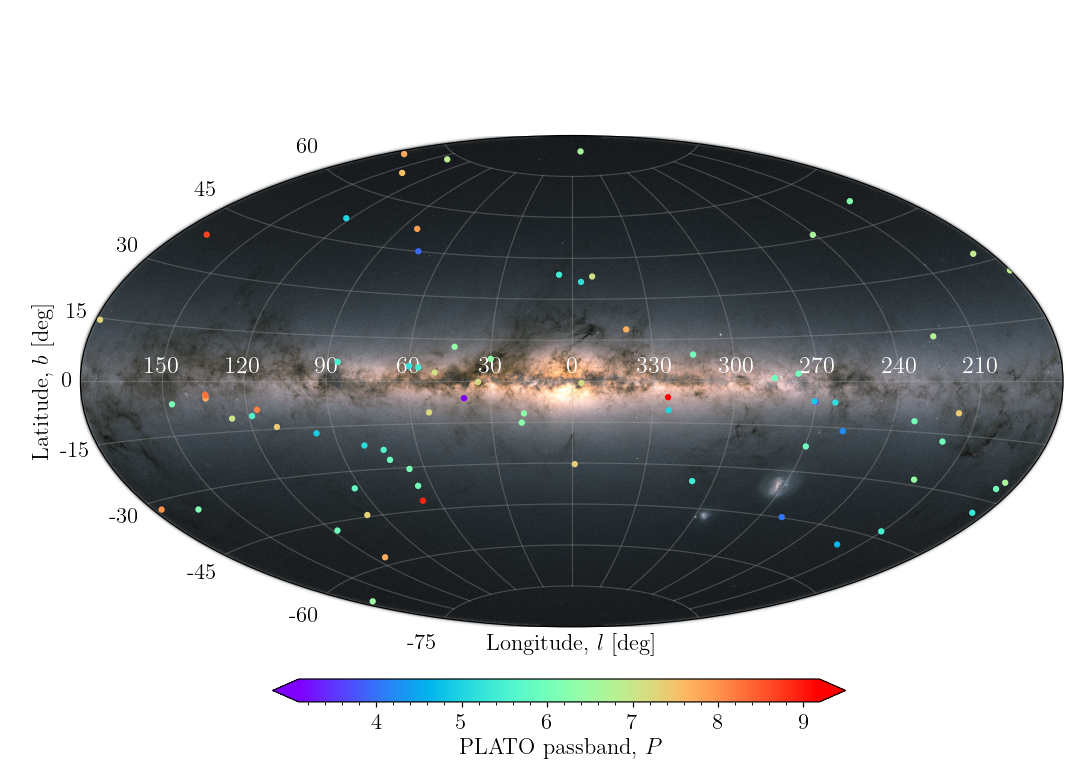

In [9]:
# Plot all stars in galactic projectionm
fig, ax = pt.drawStarsInSkyAitoff(df.ra, df.dec, column=df.Pmag, ms=10, figsize=(10,7))
# fig.savefig(fdir / f'sky_targets_aitoff.png', bbox_inches='tight', dpi=200)

### Cross-match with LOPS2 

In [11]:
# Load LOPS2 catalogue
ds = pd.read_feather(hdir / 'PlatoCS_NCAM_LOPS2.ftr')
ds.gaiaDR3 = ds.gaiaDR3.astype('float64')
ds.head()

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,R_upp,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam
0,4.677206e+18,69.189319,-62.077491,272.671893,-39.342582,1.448518,3.785840,0.560105,1.958775,3.770394,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
1,5.300300e+18,139.272369,-59.275176,278.459062,-7.011166,2.037026,2.179420,1.859075,2.213786,0.552959,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
2,5.605797e+18,111.023738,-29.303083,242.616496,-6.485724,2.335989,2.418159,2.227041,2.450408,0.339532,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6
3,5.610442e+18,105.429755,-27.934809,239.168820,-10.273803,2.369039,3.053957,1.819715,2.760549,1.768627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,6
4,5.310394e+18,140.528323,-55.010611,275.882156,-3.537435,2.402990,2.461229,2.323981,2.487886,0.246693,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,6


In [13]:
# Find stars within the LOPS2
df_match = df[df['gaiaDR3'].isin(ds['gaiaDR3'])].sort_values(by=['Gmag'])

# Save file
df_match.drop(columns='dis').reset_index(drop=True).to_feather(ddir / 'starcat_matches.ftr')

<IPython.core.display.Javascript object>


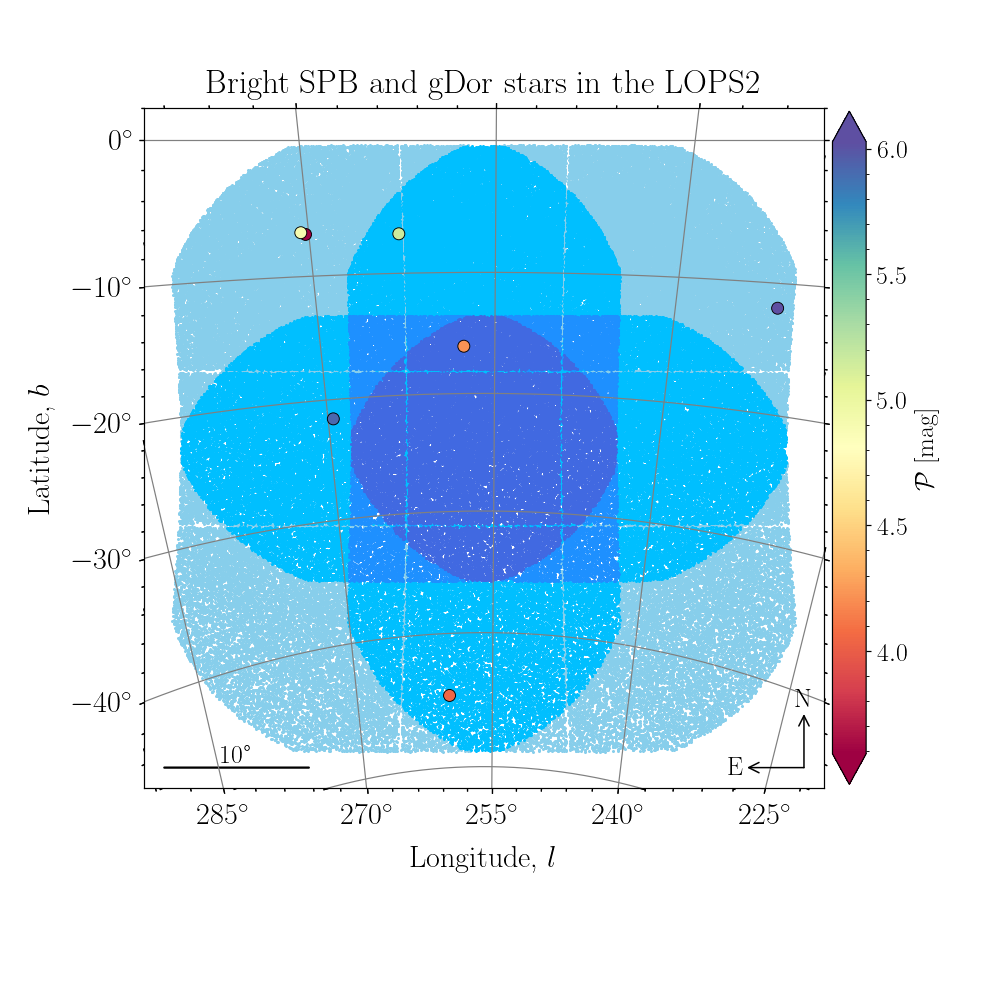

In [14]:
dx = df_match
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=250, lw=0.6, 
                          figsize=(9,9), title='Bright SPB and gDor stars in the LOPS2')
# fig.savefig(fdir / f'sky_targets_LOPS2.png', bbox_inches='tight', dpi=200)

### Stars overlapping with F-CAMs

In [29]:
ds_fcam = pd.read_feather(hdir / 'PlatoCS_FCAM_LOPS2.ftr')

<IPython.core.display.Javascript object>


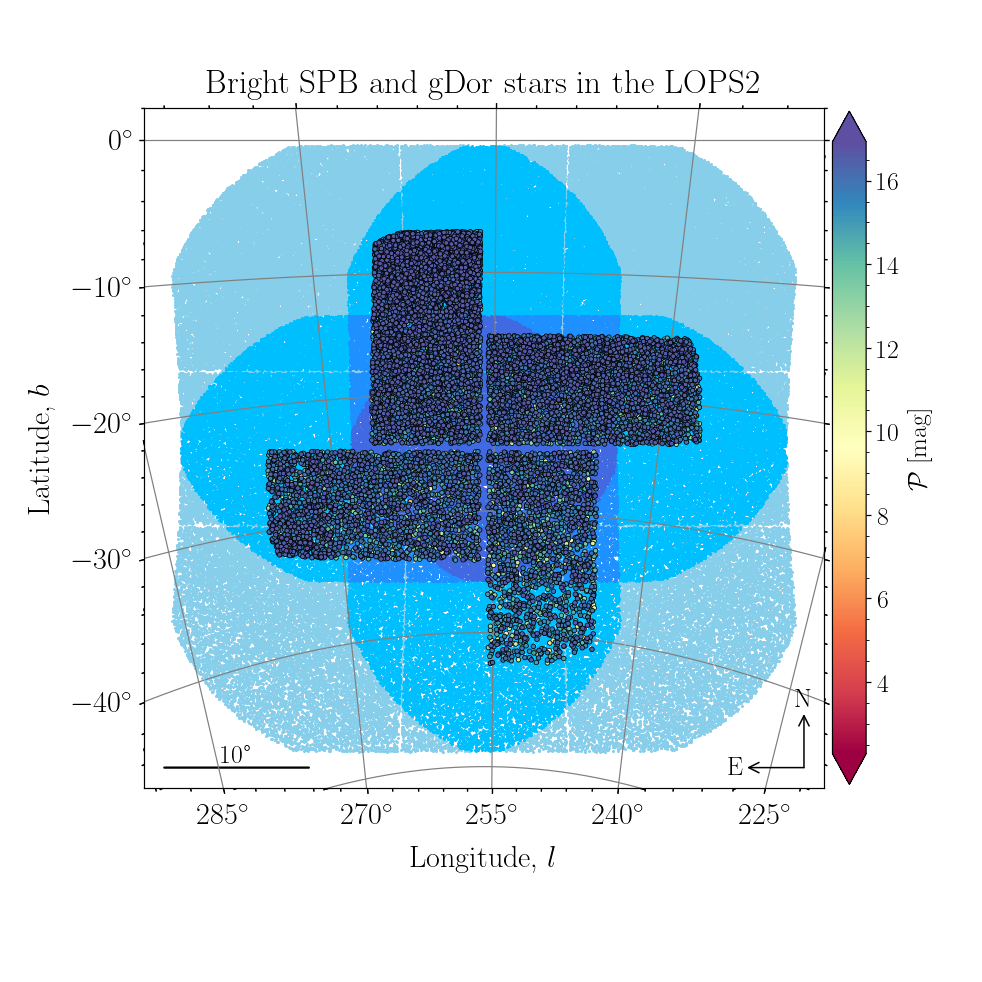

In [30]:
dx = ds_fcam.loc[::100]
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=None, lw=0.5, 
                          figsize=(9,9), title='Bright gDor/SPB stars in the LOPS2')

### Cross-match with scvPIC

In [31]:
dx = pd.read_csv(hdir / 'LOPS2scvPICtarget2.2.0.2.csv')

In [32]:
# Add Galactic coordinates
gal = SkyCoord(dx.RAdeg, dx.DEdeg, frame='icrs', unit=u.deg).galactic
# Create data frame
df = pd.DataFrame()
df['PIC']     = dx.scvPICid
df['gaiaDR3'] = dx.StarName
df['l']       = gal.l.deg
df['b']       = gal.b.deg
df['ra']      = dx.RAdeg
df['dec']     = dx.DEdeg
df['pmra']    = dx.pmRA
df['pmdec']   = dx.pmDE
df['Pmag']    = dx.PlatoMagNCAM
# dt['PBmag']   = df.PlatoMagFCAMb
# dt['PRmag']   = df.PlatoMagFCAMr
# dt['M']       = df.Mass
# dt['R']       = df.Radius
# dt['Teff']    = df.Teff
# dt['logg']    = pic.get_logg()
df['ncams']   = dx.BOLnCameraObsNCAM_T
# dt['case']    = df.caseFlag
# df['source']  = dx.PICmainSourceFlagBOL
# dt['tPIC']    = df.tPICsourceFlagNCAM_BOL
# dt['fgPIC']   = df.fgPICsourceFlag
# dt['cPIC']    = df.cPICsourceFlag
df['scvPIC']  = dx.scvPICsourceFlag

In [33]:
# Find stars within the LOPS2
df_scv = df_match[df_match['gaiaDR3'].isin(df['gaiaDR3'])].sort_values(by=['Gmag'])
df_scv

,dis,gaiaDR3,ra,dec,Gmag,BP_RP,plx,plxe,pmra,pmdec,ruwe,teff,logg,Pmag,ID


<IPython.core.display.Javascript object>


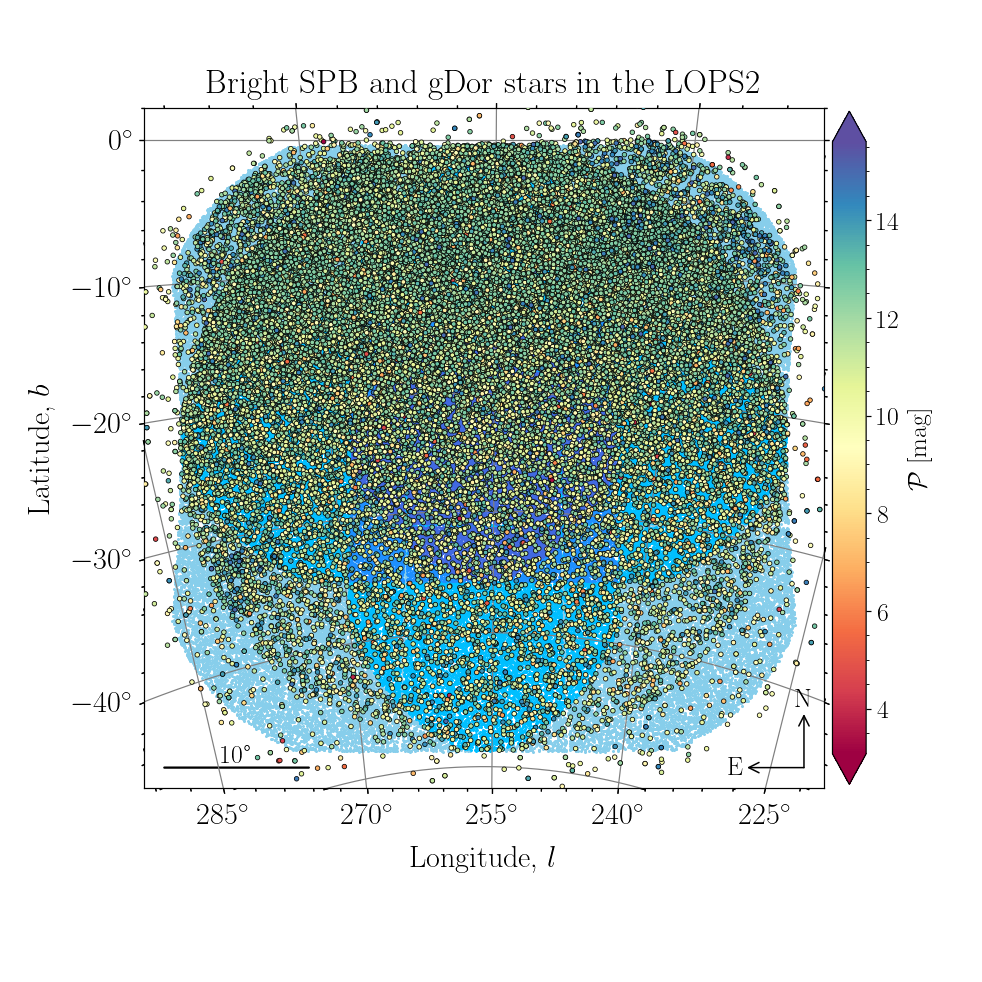

In [34]:
dx = df
fig, ax = pt.plotPlatoFOV('LOPS2', system='galactic', ncamStars=True,
                          raStars=dx.ra, decStars=dx.dec, c=dx.Pmag, 
                          clabel=r'$\mathcal{P}$ [mag]', s=None, lw=0.5, 
                          figsize=(9,9), title='Bright SPB and gDor stars in the LOPS2')

---
## 2. Check stellar saturation/blooming 
---

In [15]:
df_match = pd.read_feather(ddir / 'starcat_matches.ftr')

### HD074560 star catalogues

In [69]:
name = 'HD074560'
dt = df_match[df_match.ID == name]
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{name}_targets.ftr')
# Create contaminant catalogue
dc = ut.getContaminants(dt, ds, column='gaiaDR3', radius=750)
dc.to_feather(idir / f'starcat_{name}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.80it/s]                


In [76]:
dc[dc.Pmag < 7].gaiaDR3.astype(np.int64)

53    5318486456810851328
Name: gaiaDR3, dtype: int64

### HD069144 star catalogues

In [115]:
name = 'HD069144'
dt = df_match[df_match.ID == name]
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{name}_targets.ftr')
# Create contaminant catalogue
dc = ut.getContaminants(dt, ds, column='gaiaDR3', radius=750)
dc.to_feather(idir / f'starcat_{name}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00, 10.24it/s]                


In [116]:
dt.gaiaDR3.astype(int)

0    5519315829032177664
Name: gaiaDR3, dtype: int64

In [121]:
dc[dc.Pmag < 9]

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam,dis
5,5.519316e+18,123.396508,-46.982348,262.875187,-6.914401,8.580333,9.224472,8.049570,8.964997,1.700927,...,NaN,NaN,NaN,NaN,NaN,NaN,K,<NA>,12,34.718585
1255,5.519316e+18,123.522347,-46.917617,262.867547,-6.807108,7.010185,7.170327,6.813521,7.202489,0.610855,...,1.258116,1.218111,1.29812,3.231516,3.221875,3.240928,F,261,12,400.532549


In [96]:
# Text query of one single star
dx = sq.simbadQuery(dt.ID.iloc[0], radius=1000, maglim=21)

In [102]:
dx[dx.Pmag < 9]
dx[dx.Pmag < 9].gaiaDR3.astype(int)

0     5519315829032177152
25    5519315932102588160
Name: gaiaDR3, dtype: int64

### HD053921 star catalogues

In [104]:
name = 'HD053921'
dt = df_match[df_match.ID == name]
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{name}_targets.ftr')
# Create contaminant catalogue
dc = ut.getContaminants(dt, ds, column='gaiaDR3', radius=750)
dc.to_feather(idir / f'starcat_{name}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.79it/s]                


In [110]:
# Text query of one single star
dx = sq.simbadQuery(dt.ID.iloc[0], radius=1000, maglim=21)

In [113]:
dx[dx.Pmag < 9]
dx[dx.Pmag < 9].gaiaDR3.astype(int)

0    5480486644608749696
1    5480486640313882880
Name: gaiaDR3, dtype: int64

### HD055892 star catalogues

In [114]:
name = 'HD055892'
dt = df_match[df_match.ID == name]
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{name}_targets.ftr')
# Create contaminant catalogue
dc = ut.getContaminants(dt, ds, column='gaiaDR3', radius=750)
dc.to_feather(idir / f'starcat_{name}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  9.62it/s]                


### HD027290 star catalogues (gamma Doradus itself)

In [19]:
name = 'HD027290'
dt = df_match[df_match.ID == name]
# Create target catalogue
dt.reset_index(drop=True, inplace=True)
dt.to_feather(idir / f'starcat_{name}_targets.ftr')
# Create contaminant catalogue
dc = ut.getContaminants(dt, ds, column='gaiaDR3', radius=1000)
dc.to_feather(idir / f'starcat_{name}_contaminants.ftr')

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.26it/s]                


In [17]:
dc

,gaiaDR3,ra,dec,l,b,Pmag,PBmag,PRmag,Gmag,BP_RP,...,M,M_low,M_upp,L,L_low,L_upp,spec,evol,ncam,dis
0,4.781834e+18,64.003871,-51.487153,259.836015,-44.786543,16.167248,16.474146,15.839005,16.453276,1.022199,...,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,12,9.099084
1,4.781834e+18,64.030523,-51.503790,259.853865,-44.766755,14.719374,15.171521,14.291115,15.060142,1.346631,...,NaN,NaN,NaN,0.266401,0.258557,0.273097,K,400,12,82.964545
2,4.781834e+18,63.970331,-51.501313,259.861850,-44.803875,15.747174,16.147102,15.352159,16.071175,1.237053,...,0.757655,0.716680,0.797901,0.196718,0.185178,0.206935,K,113,12,99.916936
3,4.781834e+18,64.014953,-51.451271,259.784548,-44.787520,17.038460,17.421707,16.654659,17.356493,1.200520,...,0.756909,0.714646,0.797270,0.181921,0.155463,0.212022,G,141,12,125.580013
4,4.781834e+18,63.952246,-51.469563,259.821584,-44.821733,17.533424,17.858616,17.191193,17.827906,1.066730,...,NaN,NaN,NaN,0.185163,0.174344,0.199843,unknown,<NA>,12,136.682218
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
214,4.781834e+18,64.164783,-51.693582,260.089275,-44.644352,17.654259,19.467451,16.818470,18.135210,3.201714,...,NaN,NaN,NaN,NaN,NaN,NaN,unknown,<NA>,12,826.673920
215,4.781834e+18,63.822219,-51.686404,260.144901,-44.853130,14.747804,15.251570,14.289191,15.102738,1.448646,...,NaN,NaN,NaN,0.126587,0.121162,0.131849,K,<NA>,12,832.359929
216,4.781834e+18,64.206403,-51.290044,259.527037,-44.704882,16.663292,17.080172,16.257183,16.993038,1.273394,...,0.730973,0.688444,0.771722,0.179049,0.160109,0.196831,K,150,12,834.743709
217,4.781834e+18,63.820503,-51.689951,260.150114,-44.853381,16.999788,17.920425,16.359375,17.421118,2.124605,...,NaN,NaN,NaN,0.025455,0.020377,0.030622,M,<NA>,12,845.345139


---
## 3. Test of added benefit of Plato for Kepler targets
---

Date for first Kepler exposure: 54964.5120606 MJD = 2009-05-13 12:16:45.938 UTC

Date for first Plato exposure: 61904.51164280 MJD = 2028-05-13 12:16:45.938 UTC (assume 19 year later)


### Select a KIC

In [27]:
# kic = 'KIC5557072'
kic = 'KIC9244992'

### Create varsource file

<IPython.core.display.Javascript object>


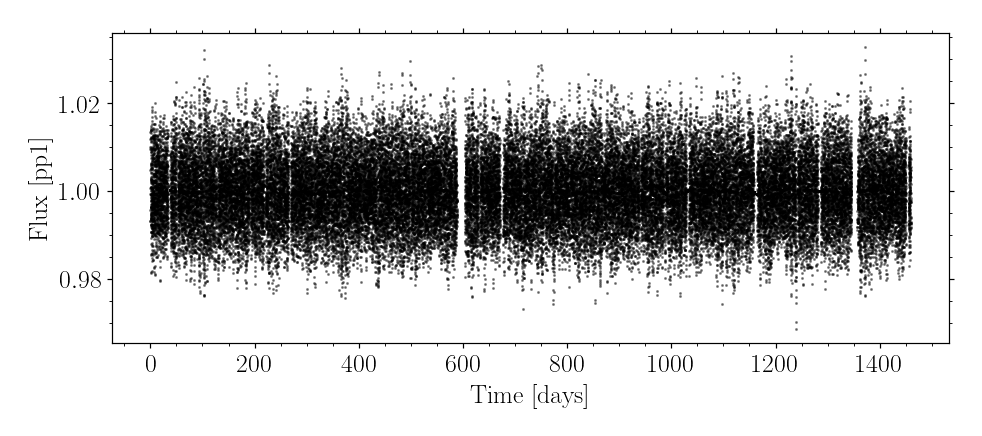

In [28]:
# Load Kepler light curve
df_kepler = pd.read_csv(ddir / f'{kic}_light_curves.dat', sep='   ', names=['time', 'flux'])
df_kepler.time -= df_kepler.time.min()
# Plot light curve
plt.figure(figsize=(9,4))
plt.plot(df_kepler.time, df_kepler.flux, 'ko', ms=1, alpha=0.4)
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

<IPython.core.display.Javascript object>


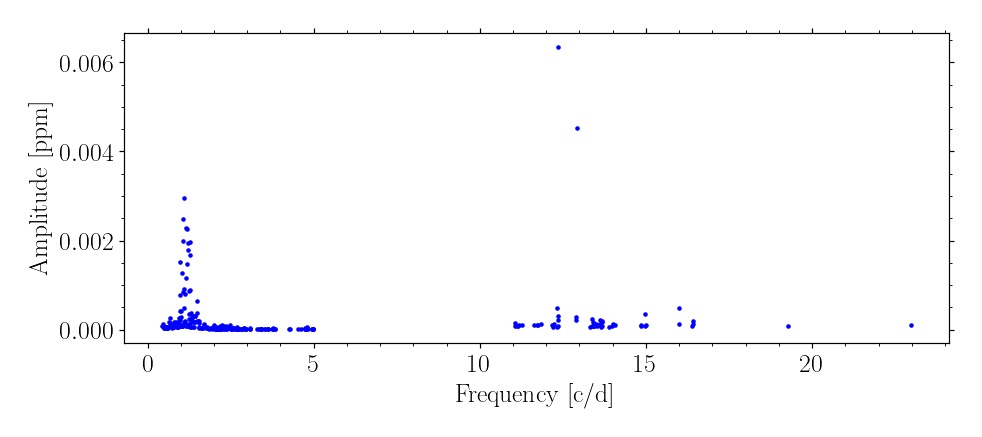

In [29]:
# Load extracted modes
dm = pd.read_csv(ddir / f'{kic}very_deep_clean.dat', 
                 sep=' ', skiprows=1, names=['freq', 'ampl', 'phase', 'snr']).dropna()
# Plot modes
plt.figure(figsize=(9,4))
plt.plot(dm.freq, dm.ampl, 'bo', ms=2)
plt.xlabel('Frequency [c/d]')
plt.ylabel('Amplitude [ppm]')
plt.tight_layout();

In [30]:
# Generate light curve from modes
time = np.arange(0, 21*ut.year()/86400, 25/86400)
flux = np.zeros_like(time)
N = dm.shape[0]
for i in range(N):
    flux += dm.ampl[i] * np.cos(2*np.pi * dm.freq[i] * time - dm.phase[i])
flux += 1
dv = pd.DataFrame({'time': time, 'flux':flux})

<IPython.core.display.Javascript object>


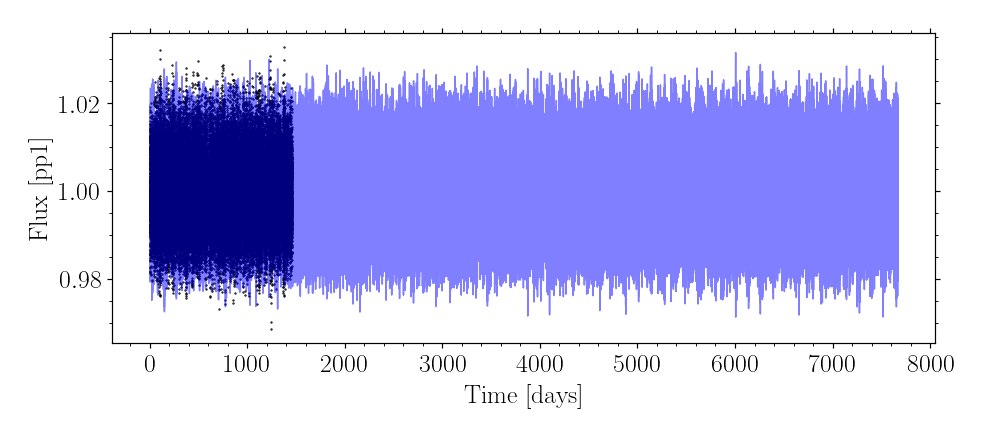

In [31]:
# Show light curve into Plato era
plt.figure(figsize=(9,4))
plt.plot(df_kepler.time, df_kepler.flux, 'k.', ms=1)
plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

In [32]:
# Take last two years and save template
nexp = round(2 * ut.year() / 25)
df = dv.copy()
df = df.loc[df.shape[0]-nexp:]
df.time -= df.time.iloc[0]
df.time *= 86400
df.flux = -2.5 * np.log10(dv.flux)
df = df.reset_index(drop=True)
df.to_csv(idir / f'varsource_{kic}.txt', sep=' ', index=False, header=False)

### Reduce Plato simulations

In [34]:
# Load light cruves
lcs = LightCurve(odir/kic , mode='multi')
files = lcs.files(suffix='ftr')
files[0]

'/lhome/nicholas/software/workdir/go_gmode/output/KIC9244992/000000001_Ncam1.1_Q1.ftr'

In [35]:
# Create table with simulation statistics
dt = lcs.stat_sim_table(ofile=odir/kic/f'table_{kic}.ftr', clean=True)
dt.head()

100%|██████████████████████████████████████████████████| 1/1 [00:00<00:00,  6.06it/s]                


,ID,gaiaDR3,ra,dec,mag,group,camera,quarter,ccd,xCCD,yCCD,rOA,xFP,yFP,ncon,SPR,NSR
0,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,1,3,1330.388761,2041.548322,11.917207,25.246998,-45.732130,19,0.032097,0.021408
1,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,2,1,2481.026017,2856.119569,12.632645,-45.958468,31.069848,19,0.017828,0.019685
2,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,5,3,1330.213303,2041.618153,11.916625,25.243839,-45.730873,19,0.032392,0.021321
3,1,2.082209e+18,300.489295,45.62096,13.737704,1,1,6,1,2481.048728,2856.174354,12.632598,-45.958877,31.068862,19,0.017318,0.019809
4,1,2.082209e+18,300.489295,45.62096,13.737704,1,2,1,3,1341.989386,2052.607567,11.901116,25.455809,-45.533064,19,0.031597,0.020388


<IPython.core.display.Javascript object>


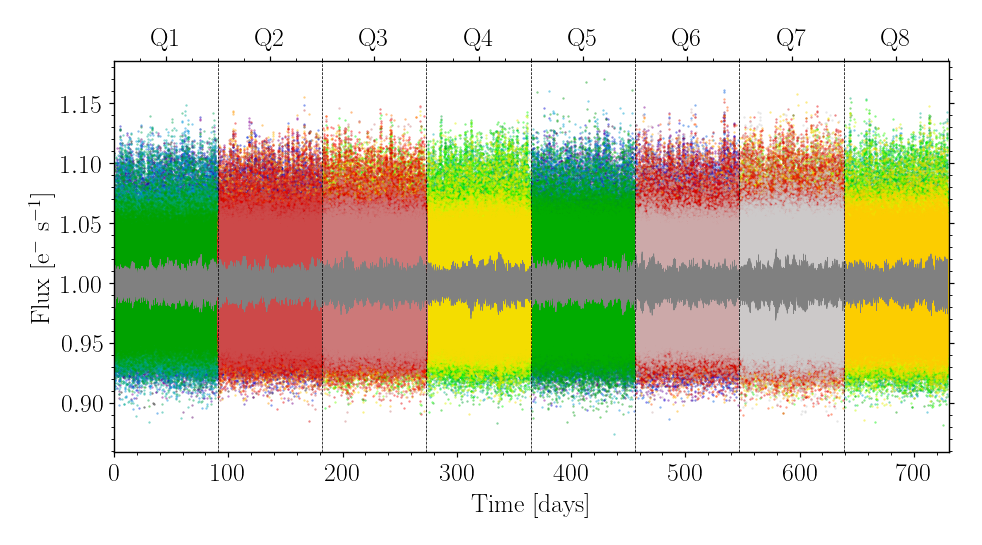

In [36]:
# Show all light curves
fig, ax = lcs.plot_multi(suffix='ftr', group=False, camera=False, quarter=False, 
                         flux_median=144, alpha=0.5, figsize=(9,5));

In [37]:
# Post-processing into final light curve
lc = lcs.merge(
    suffix='ftr',
    flux_group_mean=True,
    binsize=600,
    flux_offset=True,
    flux_error=True,
    ofile= odir/kic/f'lc_{kic}.ftr'
)

Processing star ID 000000001
-------------------------------------------------------
Merging 96 light curves


100%|██████████████████████████████████████████████████| 96/96 [00:34<00:00,  2.80it/s]              


Sorting data after timings
Averaging data from same camera group
Binning data per 600s
Corrrecting flux offset of 1.0 ppm
Calculating flux errors
Saving light curve
Total execution time: 0:00:46.595871 [h:mm:ss]
-------------------------------------------------------


In [38]:
# Get light curve and add time offset since Kepler
df_plato = lc.data()
df_plato.time /= 86400 
df_plato.time += 19 * ut.year() / 86400

<IPython.core.display.Javascript object>


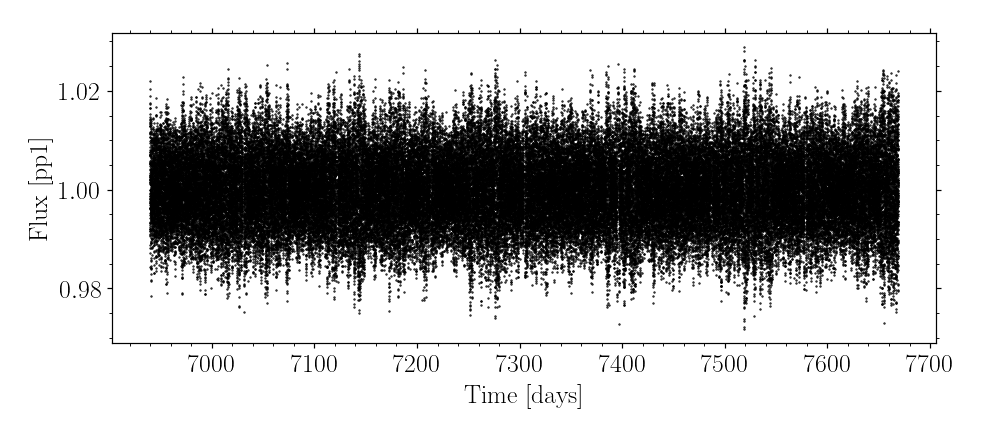

In [42]:
# Show Plato light curve
plt.figure(figsize=(9,4))
plt.plot(df_plato.time, df_plato.flux, 'k.', ms=1)
# plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();

In [40]:
# Create new Kepler+Plato light curve
df_comb = pd.concat((df_kepler, df_plato))
df_comb.to_csv(ddir/f'{kic}_combined.csv', sep=',', index=False, header=True)

<IPython.core.display.Javascript object>


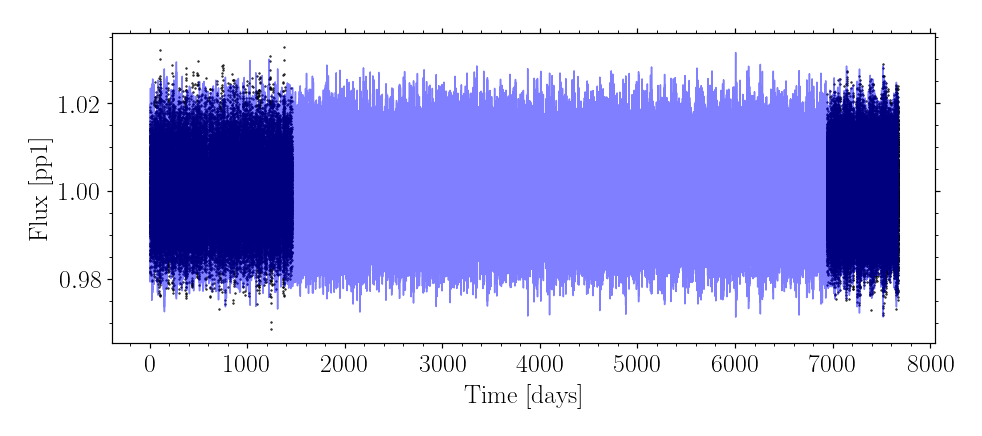

In [41]:
# Show light curve into Plato era
plt.figure(figsize=(9,4))
plt.plot(df_comb.time, df_comb.flux, 'k.', ms=1)
plt.plot(dv.time, dv.flux, '-', c='b', lw=1, alpha=0.5);
plt.xlabel('Time [days]')
plt.ylabel('Flux [pp1]')
plt.tight_layout();